## Section 1 — Install & Import Libraries

In [1]:
# Install required packages (run once)
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Notebook display settings
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.facecolor'] = '#FAFAFA'
plt.rcParams['figure.facecolor'] = '#F8FAFC'

print("All libraries imported successfully.")
print(f"   pandas {pd.__version__} | numpy {np.__version__}")


All libraries imported successfully.
   pandas 2.2.2 | numpy 2.0.2


## Section 2 — Load Dataset


In [2]:
DATA_PATH = 'Country-data.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


Dataset loaded: 167 rows × 10 columns


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
# Quick overview
print("── Column Types ──")
print(df.dtypes)
print(f"\nMissing values per column:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")


── Column Types ──
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate rows: 0


## Section 3 — Data Cleaning Pipeline


In [4]:
# Step 3a — Strip column whitespace
df.columns = df.columns.str.strip()
print("Columns after strip:", list(df.columns))

# Step 3b — Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Dropped {before - len(df)} duplicate row(s). Remaining: {len(df)}")

# Step 3c — Force numeric types (skip 'country')
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 3d — Median imputation
for col in df.select_dtypes(include=np.number).columns:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  Imputed {n_missing} missing value(s) in '{col}'")

print(f"\nMissing values remaining: {df.isnull().sum().sum()}")
df.describe().round(2)


Columns after strip: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
Dropped 0 duplicate row(s). Remaining: 167

Missing values remaining: 0


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


## Section 4 — Feature Scaling

In [5]:
# Isolate continuous features (drop string identifier)
country_names = df['country']
features = df.drop(columns=['country'])

print(f"Features used for clustering ({len(features.columns)}):")
print(list(features.columns))

# Fit StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(features)

print(f"\nScaled matrix shape: {X.shape}")
print(f"Mean ≈ {X.mean():.4f} (should be ~0)")
print(f"Std  ≈ {X.std():.4f}  (should be ~1)")


Features used for clustering (9):
['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Scaled matrix shape: (167, 9)
Mean ≈ 0.0000 (should be ~0)
Std  ≈ 1.0000  (should be ~1)


## Section 5 — Elbow Method (K ∈ [2, 10])


In [6]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    print(f"  K={k:2d} → Inertia = {km.inertia_:,.1f}")



  K= 2 → Inertia = 1,050.2
  K= 3 → Inertia = 831.4
  K= 4 → Inertia = 700.5
  K= 5 → Inertia = 620.2
  K= 6 → Inertia = 558.5
  K= 7 → Inertia = 495.8
  K= 8 → Inertia = 457.6
  K= 9 → Inertia = 427.8
  K=10 → Inertia = 403.2


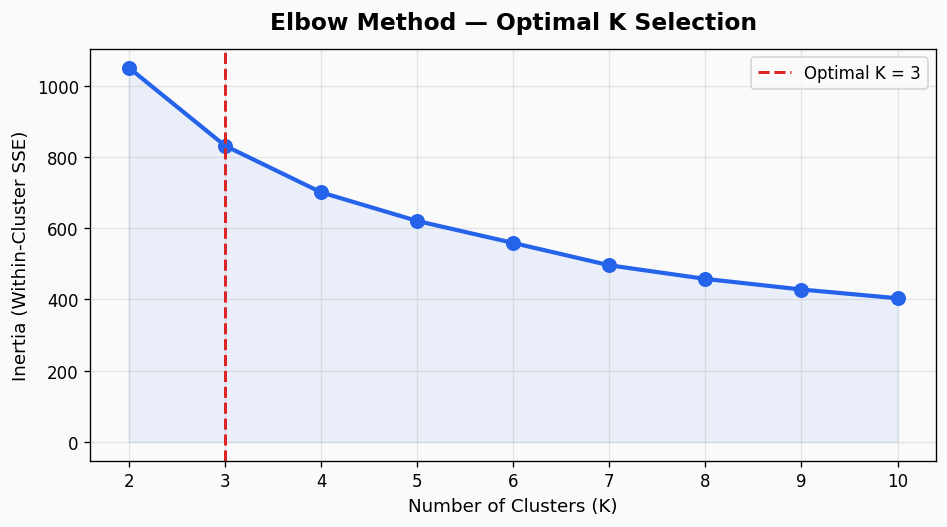


The curve 'elbows' most sharply at K = 3 → chosen as best_k.


In [7]:
# ── Elbow Curve Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(k_range), inertias, 'o-', color='#2563EB', linewidth=2.5, markersize=8)
ax.axvline(x=3, color='#DC2626', linestyle='--', linewidth=1.8, label='Optimal K = 3')
ax.fill_between(list(k_range), inertias, alpha=0.08, color='#2563EB')
ax.set_title('Elbow Method — Optimal K Selection', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Number of Clusters (K)', fontsize=11)
ax.set_ylabel('Inertia (Within-Cluster SSE)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nThe curve 'elbows' most sharply at K = 3 → chosen as best_k.")


## Section 6 — Train K-Means Model (best_k = 3)

In [8]:
best_k = 3

km_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = km_model.fit_predict(X)

print(f"K-Means trained with k = {best_k}")
print("\nCluster distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index().to_string())

# Cluster-level summary
summary = df.groupby('KMeans_Cluster')[
    ['child_mort', 'life_expec', 'gdpp', 'income', 'health', 'total_fer']
].mean().round(2)
print("\nCluster mean statistics:")
summary


K-Means trained with k = 3

Cluster distribution:
KMeans_Cluster
0    36
1    47
2    84

Cluster mean statistics:


,child_mort,life_expec,gdpp,income,health,total_fer
KMeans_Cluster,,,,,,
0,5.00,80.13,42494.44,45672.22,8.81,1.75
1,92.96,59.19,1922.38,3942.40,6.39,5.01
2,21.93,72.81,6486.45,12305.60,6.20,2.31


## Section 7 — Evaluate: Silhouette Score

In [9]:
sil_score = silhouette_score(X, df['KMeans_Cluster'])
print(f"Silhouette Score (K-Means, k=3): {sil_score:.4f}")

if sil_score > 0.5:
    quality = "Strong"
elif sil_score > 0.25:
    quality = "Moderate"
else:
    quality = "Weak"

print(f"Cluster separation quality: {quality}")


Silhouette Score (K-Means, k=3): 0.2833
Cluster separation quality: Moderate


## Section 8 — DBSCAN Comparative Model


In [10]:
db_model = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = db_model.fit_predict(X)

labels = df['DBSCAN_Cluster']
n_clusters = len(set(labels)) - (1 if -1 in labels.values else 0)
n_noise    = (labels == -1).sum()

print(f"DBSCAN Results (eps=1.5, min_samples=5):")
print(f"  Clusters found : {n_clusters}")
print(f"  Noise points   : {n_noise}")
print(f"\nLabel distribution:\n{labels.value_counts().sort_index().to_string()}")

# Show noise (outlier) countries
noise_countries = df[df['DBSCAN_Cluster'] == -1]['country'].tolist()
print(f"\nOutlier countries ({len(noise_countries)}):")
print(', '.join(noise_countries[:20]), '...' if len(noise_countries) > 20 else '')


DBSCAN Results (eps=1.5, min_samples=5):
  Clusters found : 1
  Noise points   : 30

Label distribution:
DBSCAN_Cluster
-1     30
 0    137

Outlier countries (30):
Angola, Brunei, Central African Republic, Congo, Dem. Rep., Congo, Rep., Equatorial Guinea, Gabon, Haiti, Iraq, Ireland, Kiribati, Kuwait, Lesotho, Liberia, Luxembourg, Malta, Micronesia, Fed. Sts., Mongolia, Nigeria, Norway ...


## Section 9 — PCA 2D Projection & Cluster Scatterplot


In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
exp_var = pca.explained_variance_ratio_

print(f"PC1 explains {exp_var[0]*100:.1f}% of variance")
print(f"PC2 explains {exp_var[1]*100:.1f}% of variance")
print(f"Total variance captured: {exp_var.sum()*100:.1f}%")


PC1 explains 46.0% of variance
PC2 explains 17.2% of variance
Total variance captured: 63.1%


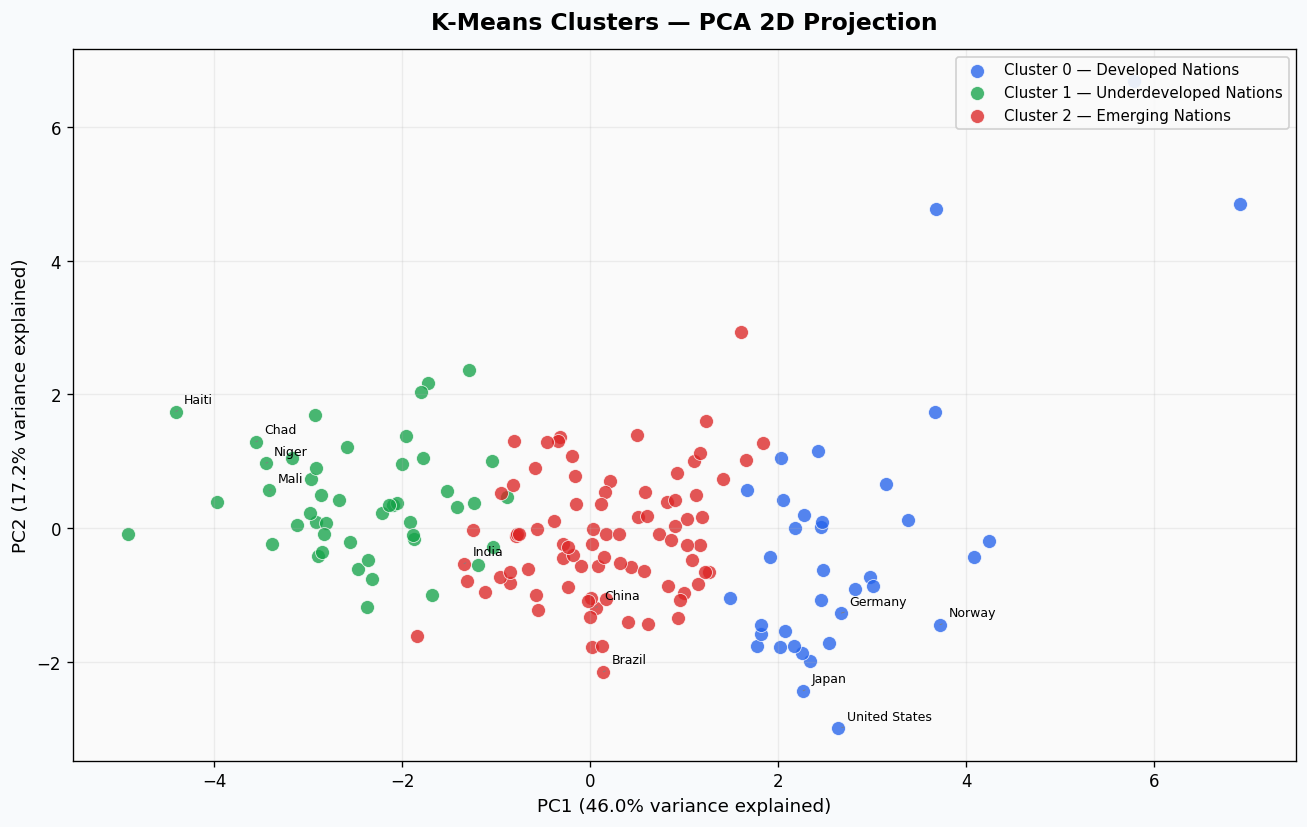

In [12]:
COLORS = ['#2563EB', '#16A34A', '#DC2626']
CLUSTER_NAMES = {
    0: 'Cluster 0 — Developed Nations',
    1: 'Cluster 1 — Underdeveloped Nations',
    2: 'Cluster 2 — Emerging Nations'
}

# Notable countries to annotate
HIGHLIGHTS = ['United States', 'Germany', 'Norway', 'Japan',
              'Niger', 'Haiti', 'Mali', 'Chad',
              'India', 'China', 'Brazil', 'Mexico']

fig, ax = plt.subplots(figsize=(11, 7))

for cl in sorted(df['KMeans_Cluster'].unique()):
    mask = df['KMeans_Cluster'] == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLORS[cl], label=CLUSTER_NAMES[cl],
               alpha=0.78, s=70, edgecolors='white', linewidths=0.5)

# Annotations
for idx, row in df.iterrows():
    if row['country'] in HIGHLIGHTS:
        ax.annotate(row['country'],
                    (X_pca[idx, 0], X_pca[idx, 1]),
                    fontsize=7.5,
                    xytext=(5, 5), textcoords='offset points',
                    arrowprops=dict(arrowstyle='-', lw=0.5, color='gray'))

ax.set_title('K-Means Clusters — PCA 2D Projection', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel(f'PC1 ({exp_var[0]*100:.1f}% variance explained)', fontsize=11)
ax.set_ylabel(f'PC2 ({exp_var[1]*100:.1f}% variance explained)', fontsize=11)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


### Cluster Feature Heatmap

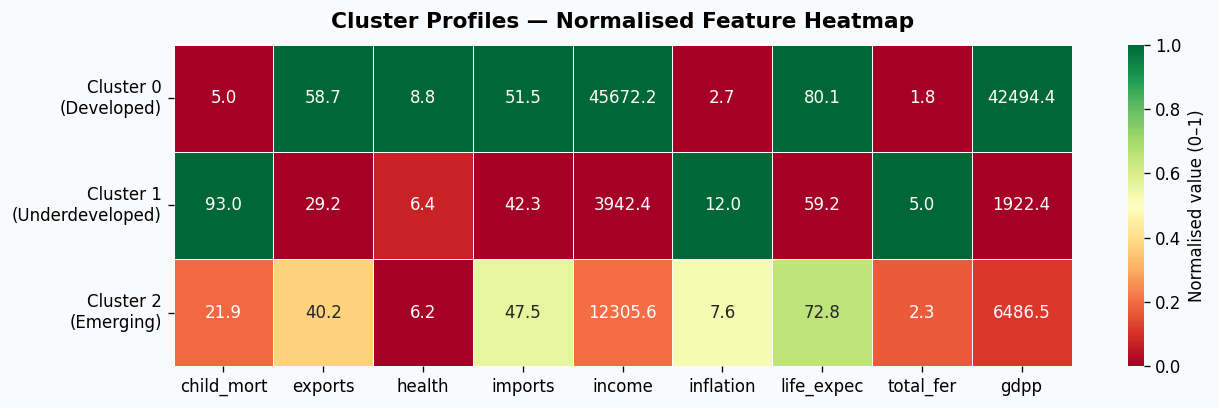

In [13]:
cluster_means = df.groupby('KMeans_Cluster')[
    ['child_mort','exports','health','imports','income','inflation','life_expec','total_fer','gdpp']
].mean()

# Normalise each feature 0-1 for visual comparison
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
cluster_norm.index = ['Cluster 0\n(Developed)', 'Cluster 1\n(Underdeveloped)', 'Cluster 2\n(Emerging)']

fig, ax = plt.subplots(figsize=(11, 3.5))
sns.heatmap(cluster_norm, annot=cluster_means.round(1), fmt='.1f',
            cmap='RdYlGn', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Normalised value (0–1)'})
ax.set_title('Cluster Profiles — Normalised Feature Heatmap', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


## Section 10 — Observations & Conclusions

### Observation 1 — The High-Mortality Cluster (Cluster 1)
Cluster 1 is where things look the bleakest. These 47 countries average around 93 child deaths per 1,000 births and a life expectancy of just 59 years — numbers that are hard to read. Niger, Mali, Chad, and Haiti are typical examples here. One thing that stands out is how high the fertility rates are in this group (around 5 children per woman). That's not a coincidence — in places where child mortality is this high, families tend to have more children. This cluster clearly needs the most attention from a health and development standpoint.

---

### Observation 2 — The Wealthiest Nations (Cluster 0)
On the other end of the scale, Cluster 0 groups together 36 of the world's richest countries — the US, Germany, Norway, Japan and similar nations. GDP per capita here averages around $42,000, which is roughly 10 times what you see in the middle cluster. Life expectancy is close to 80, child mortality is very low, and these countries spend the most on healthcare as a share of GDP. Fertility rates are also low (around 1.75), which is pretty typical for wealthy post-industrial economies.

---

### Observation 3 — The Middle Ground (Cluster 2)
This is the biggest group with 84 countries — roughly half the dataset. It covers a wide range of developing and emerging economies like India, China, Brazil, and Mexico. GDP per capita sits around $6,500, child mortality is moderate (~22 per 1,000), and life expectancy is around 73 years. The cluster is quite mixed internally, which makes sense — it lumps together countries that are almost developed with ones that still have a long way to go.

---

### Observation 4 — What the Silhouette Score Is Telling Us
The silhouette score came out at 0.2833, which is moderate. That might sound underwhelming but it actually makes sense here. Development isn't a clean three-way split — it's more of a sliding scale. Countries like Vietnam or Romania sit somewhere between clusters, and that overlap is what pulls the score down. The clustering is still meaningful, it just reflects the reality that you can't draw perfectly clean lines around something as complex as national development.

---

### Observation 5 —  What DBSCAN Found
Running DBSCAN flagged 30 countries as outliers — points that don't really belong to any dense group. These tend to be unusual cases: Gulf states with high GDP but poor health outcomes, or tiny island nations with very high trade volumes relative to their size. K-Means would've forced these into a cluster anyway, which could skew the results. Having DBSCAN catch them separately is useful — it's a good reminder that averages don't tell the whole story.


In [14]:
print("=" * 55)
print("  ANALYSIS SUMMARY")
print("=" * 55)
print(f"  Dataset          : {df.shape[0]} countries × 9 features")
print(f"  K-Means clusters : 3")
print(f"  Silhouette Score : {silhouette_score(X, df['KMeans_Cluster']):.4f}")
print(f"  DBSCAN outliers  : {(df['DBSCAN_Cluster'] == -1).sum()} countries")
print(f"  PCA variance     : {pca.explained_variance_ratio_.sum()*100:.1f}% (2 components)")
print("=" * 55)


  ANALYSIS SUMMARY
  Dataset          : 167 countries × 9 features
  K-Means clusters : 3
  Silhouette Score : 0.2833
  DBSCAN outliers  : 30 countries
  PCA variance     : 63.1% (2 components)
